In [52]:
print("hello!")

hello!


loading datasets . . .
printing example sample!


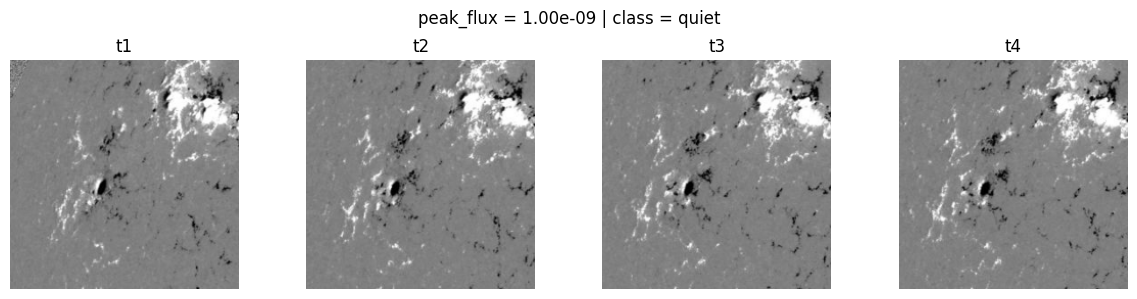

loading current models . . .
loaded current baseline model
loaded current temporal attention model
loaded current frame-difference model
summarizing errors . . .

Baseline:
Mean: 0.000377535841033341
Std: 0.00020025238073436688
Median: 0.00037417416626794875
90th percentile: 0.0006082751338908565
95th percentile: 0.0006607282950405356
99th percentile: 0.0008984453039179294
Max: 0.0011873346184074762


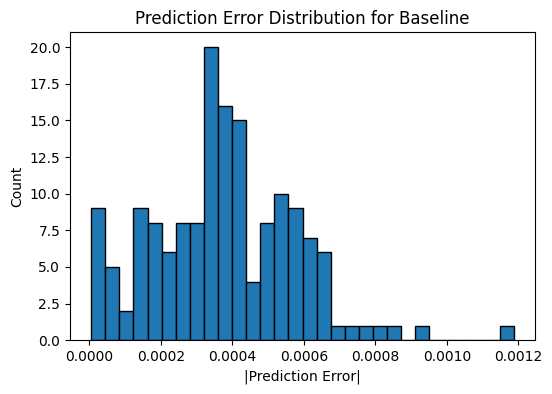

summarizing errors . . .

Temporal Attention:
Mean: 0.0023089686713281578
Std: 0.0002737870047628605
Median: 0.002343578215970865
90th percentile: 0.0026299686199536152
95th percentile: 0.002677104076164394
99th percentile: 0.002791873134647176
Max: 0.0028783838020095542


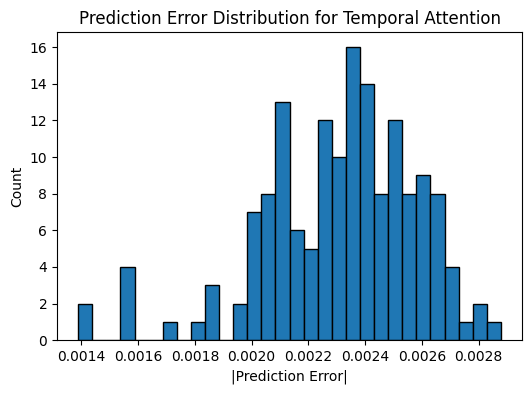

summarizing errors . . .

Temporal Difference:
Mean: 0.0012151143781435332
Std: 0.0005337582975333477
Median: 0.0011629174218902305
90th percentile: 0.0019481321493458382
95th percentile: 0.0021120197682535035
99th percentile: 0.002322960862902619
Max: 0.0023757345492185777


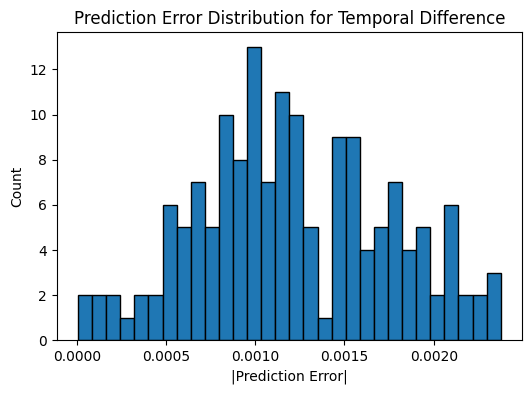

printing grad-cam example: 


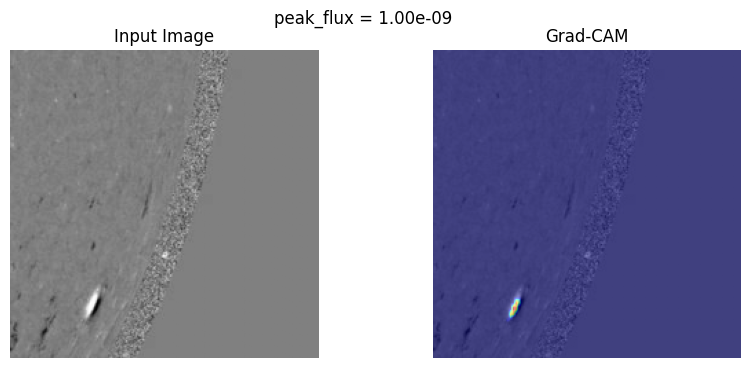

In [85]:
import os
from pathlib import Path
import pandas as pd
import os
import numpy as np
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

%run project.ipynb

In [54]:
test_loader = DataLoader(test_sequence, batch_size=8, shuffle=False)
test_loader_single = DataLoader(test_single, batch_size=8, shuffle=False)

In [55]:
# train in epochs
epochs = 10

## Baseline Training

In [56]:
# make model with L1 loss function (MAE)
model = BaselineCNN().to(device)
loss_fn = nn.L1Loss()
# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    # training
    model.train()
    # accumulate loss
    train_loss = 0
    # for input images and labels
    for x, y, z in train_loader_single:
        # move data to device
        x = x.to(device).float()
        y = y.to(device).float()
        # reset gradients - torch accumulates and stacks gradients by defualt
        # clears old gradients in between batches
        optimizer.zero_grad()
        # forward pass, we get predictions
        preds = model(x)
        # compute loss 
        loss = loss_fn(preds, y)
        # backward propagation (computes gradients of loss for all model parameters)
        # learning signal
        loss.backward()
        # update weights/model params using gradients
        optimizer.step()
        # acc loss
        train_loss += loss.item()
    # average loss
    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y, z in val_loader_single:
            # move data to device
            x = x.to(device).float()
            y = y.to(device).float()
            # prediciton
            preds = model(x)
            # loss 
            loss = loss_fn(preds, y)
            # acc loss
            val_loss += loss.item()
    # average validation los
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch 1/10 | Train Loss: 0.006580 | Val Loss: 0.004863
Epoch 2/10 | Train Loss: 0.002534 | Val Loss: 0.000654
Epoch 3/10 | Train Loss: 0.002092 | Val Loss: 0.003152
Epoch 4/10 | Train Loss: 0.002351 | Val Loss: 0.003161
Epoch 5/10 | Train Loss: 0.001443 | Val Loss: 0.002025
Epoch 6/10 | Train Loss: 0.001470 | Val Loss: 0.000249
Epoch 7/10 | Train Loss: 0.001299 | Val Loss: 0.001138
Epoch 8/10 | Train Loss: 0.000844 | Val Loss: 0.001507
Epoch 9/10 | Train Loss: 0.001306 | Val Loss: 0.000887
Epoch 10/10 | Train Loss: 0.000660 | Val Loss: 0.000377


In [86]:
model.eval()
test_loss = 0
with torch.no_grad():
    for x, y, z in test_loader_single:
        x = x.to(device).float()
        y = y.to(device).float()

        preds = model(x)
        loss = loss_fn(preds, y)

        test_loss += loss.item()

test_loss /= len(test_loader)

print("Final Test Loss:", test_loss)

ValueError: not enough values to unpack (expected 5, got 4)

In [58]:
torch.save(model.state_dict(), "baseline_3.pth")

## Temporal Attention Training

In [73]:
# use baseline cnn as shared encoder inside temporal model
model = AttentionTemporalCNN().to(device)
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    # training
    model.train()
    train_loss = 0
    for x, y , z in train_loader:
        x = x.to(device).float()   # [B, 4, 1, H, W]
        y = y.to(device).float()
        optimizer.zero_grad()
        preds, attn = model(x)     # unpack outputs
        loss = loss_fn(preds, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y, z in val_loader:
            x = x.to(device).float()
            y = y.to(device).float()
            preds, attn = model(x)
            loss = loss_fn(preds, y)
            val_loss += loss.item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

Epoch 1/10 | Train: 0.013368 | Val: 0.001326
Epoch 2/10 | Train: 0.003676 | Val: 0.000884
Epoch 3/10 | Train: 0.003165 | Val: 0.001583
Epoch 4/10 | Train: 0.003599 | Val: 0.001287
Epoch 5/10 | Train: 0.002754 | Val: 0.002447
Epoch 6/10 | Train: 0.002144 | Val: 0.002735
Epoch 7/10 | Train: 0.001647 | Val: 0.001265
Epoch 8/10 | Train: 0.003265 | Val: 0.002207
Epoch 9/10 | Train: 0.001533 | Val: 0.000791
Epoch 10/10 | Train: 0.001542 | Val: 0.002297


In [74]:
test_loss = 0
all_preds = []
all_targets = []
all_attn = []
model.eval()
with torch.no_grad():
    for x, y, z in test_loader:
        x = x.to(device).float()
        y = y.to(device).float()

        preds, attn = model(x)
        loss = loss_fn(preds, y)
        test_loss += loss.item()

        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())
        all_attn.append(attn.cpu())

test_loss /= len(test_loader)

print(f"Final Test Loss: {test_loss:.6f}")

all_attn = torch.cat(all_attn, dim=0)   # [N, 4, 1]
mean_attn = all_attn.mean(dim=0).squeeze()  # [4]
print(mean_attn)

Final Test Loss: 0.002123
tensor([0.2500, 0.2500, 0.2500, 0.2500])


In [75]:
torch.save(model.state_dict(), "attention_2.pth")

## Frame Difference Training

In [78]:
base_cnn = BaselineCNN().to(device)
model = FrameDiffModel(base_cnn).to(device)
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    # training
    model.train()
    train_loss = 0
    for x, y, _ in train_loader:
        x = x.to(device).float()   # [B, 4, 1, H, W]
        y = y.to(device).float()
        optimizer.zero_grad()
        preds = model(x)           # [B]
        loss = loss_fn(preds, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y, _ in val_loader:
            x = x.to(device).float()
            y = y.to(device).float()
            preds = model(x)
            loss = loss_fn(preds, y)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

Epoch 1/10 | Train: 0.011391 | Val: 0.004328
Epoch 2/10 | Train: 0.003271 | Val: 0.001801
Epoch 3/10 | Train: 0.002353 | Val: 0.002547
Epoch 4/10 | Train: 0.002889 | Val: 0.000818
Epoch 5/10 | Train: 0.002459 | Val: 0.002216
Epoch 6/10 | Train: 0.002840 | Val: 0.003757
Epoch 7/10 | Train: 0.001540 | Val: 0.001315
Epoch 8/10 | Train: 0.001857 | Val: 0.001182
Epoch 9/10 | Train: 0.001651 | Val: 0.002218
Epoch 10/10 | Train: 0.001686 | Val: 0.001216


In [81]:
test_loss = 0
all_preds = []
all_targets = []

model.eval()  # or diffmodel if that's your variable name

with torch.no_grad():
    for x, y, _ in test_loader:
        x = x.to(device).float()   # [B, T, C, H, W]
        y = y.to(device).float()

        preds = model(x)      # [B] (no attention output)
        loss = loss_fn(preds, y)

        test_loss += loss.item()

        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())

test_loss /= len(test_loader)

print(f"Final Test Loss: {test_loss:.6f}")

Final Test Loss: 0.001314


In [83]:
torch.save(model.state_dict(), "framediff_model_2.pth")